# Low-Light Image Enhancement using Zero-DCE
## Zero-Reference Deep Curve Estimation with LOL-v2 Dataset

## 1. LOAD DATA

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from tqdm import tqdm
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Define data paths
BASE_PATH = Path('LOL-v2')
TRAIN_PATH = BASE_PATH / 'Real_captured' / 'Train'
TEST_PATH = BASE_PATH / 'Real_captured' / 'Test'

print(f"Base path: {BASE_PATH}")
print(f"Train path exists: {TRAIN_PATH.exists()}")
print(f"Test path exists: {TEST_PATH.exists()}")

Using device: cuda
Base path: LOL-v2
Train path exists: True
Test path exists: True


In [2]:
# Load image file paths
def load_image_pairs(data_path):
    """Load low-light and normal image pairs"""
    low_path = data_path / 'Low'
    normal_path = data_path / 'Normal'
    
    low_images = sorted([f for f in os.listdir(low_path) if f.endswith(('.jpg', '.png'))])
    normal_images = sorted([f for f in os.listdir(normal_path) if f.endswith(('.jpg', '.png'))])
    
    pairs = []
    for low_img, normal_img in zip(low_images, normal_images):
        pairs.append({
            'low': str(low_path / low_img),
            'normal': str(normal_path / normal_img),
            'filename': low_img
        })
    
    return pairs

# Load training and test data
train_pairs = load_image_pairs(TRAIN_PATH)
test_pairs = load_image_pairs(TEST_PATH)

print(f"Training pairs: {len(train_pairs)}")
print(f"Test pairs: {len(test_pairs)}")
print(f"Sample pair: {train_pairs[0]}")

Training pairs: 689
Test pairs: 100
Sample pair: {'low': 'LOL-v2\\Real_captured\\Train\\Low\\low00001.png', 'normal': 'LOL-v2\\Real_captured\\Train\\Normal\\normal00001.png', 'filename': 'low00001.png'}


## 2. EDA (Exploratory Data Analysis)

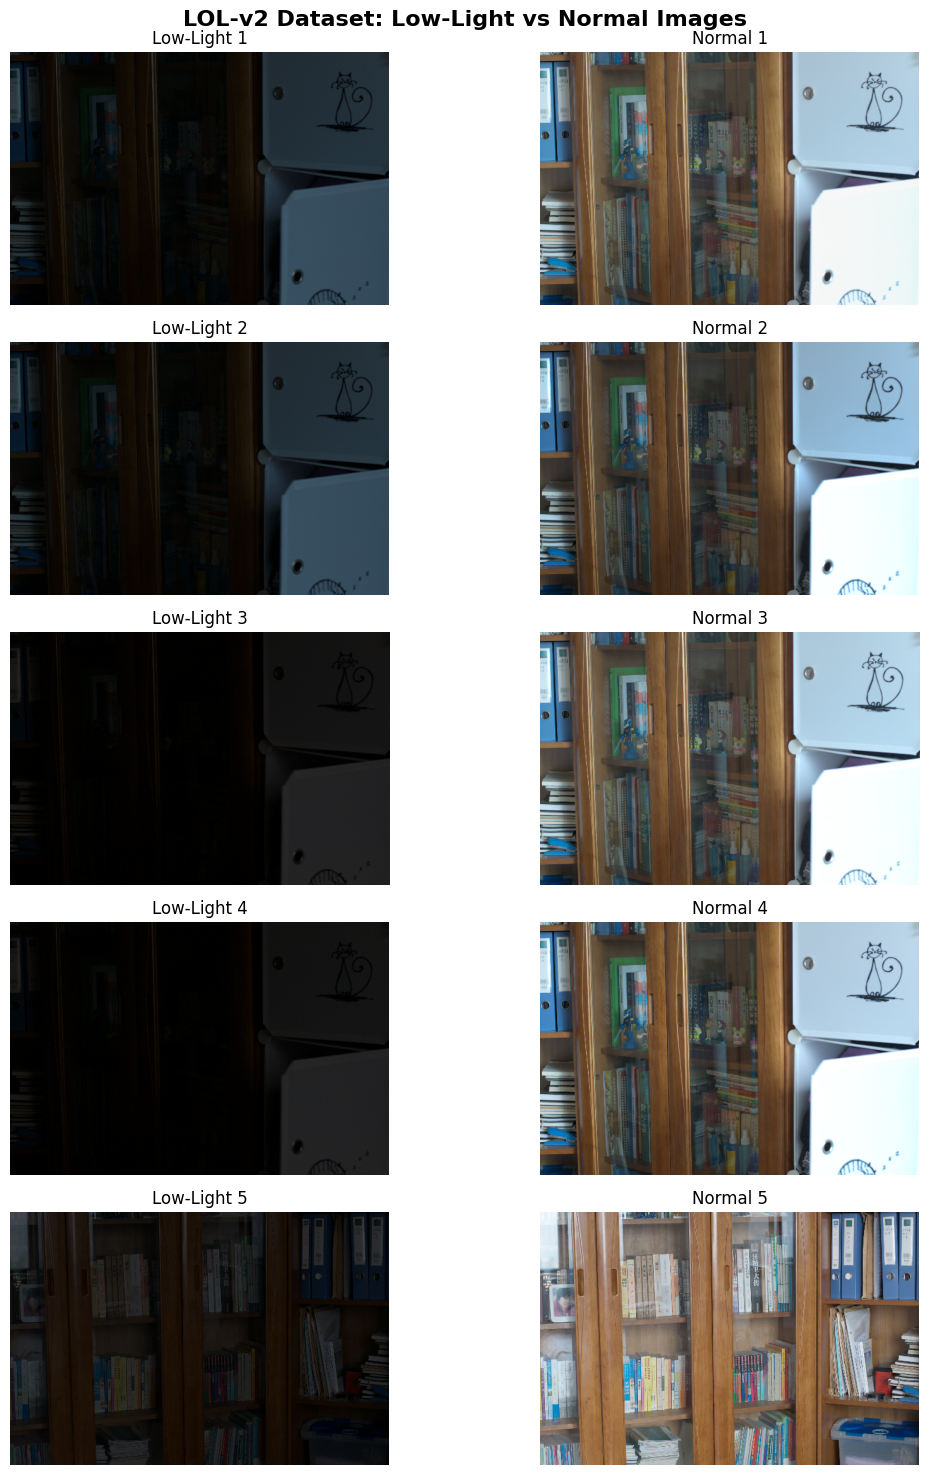

Sample images displayed successfully


In [3]:
# Visualize sample image pairs
fig, axes = plt.subplots(5, 2, figsize=(12, 15))
fig.suptitle('LOL-v2 Dataset: Low-Light vs Normal Images', fontsize=16, fontweight='bold')

for idx in range(5):
    pair = train_pairs[idx]
    
    low_img = cv2.imread(pair['low'])
    low_img = cv2.cvtColor(low_img, cv2.COLOR_BGR2RGB)
    
    normal_img = cv2.imread(pair['normal'])
    normal_img = cv2.cvtColor(normal_img, cv2.COLOR_BGR2RGB)
    
    axes[idx, 0].imshow(low_img)
    axes[idx, 0].set_title(f'Low-Light {idx+1}')
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(normal_img)
    axes[idx, 1].set_title(f'Normal {idx+1}')
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()
print("Sample images displayed successfully")

In [4]:
# Analyze image properties
def analyze_image_stats(img_path):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return {
        'shape': img.shape,
        'mean': img_rgb.mean(axis=(0, 1)),
        'std': img_rgb.std(axis=(0, 1)),
        'min': img_rgb.min(),
        'max': img_rgb.max()
    }

# Analyze low-light vs normal statistics
print("\n=== IMAGE STATISTICS ===")
low_stats = []
normal_stats = []

for pair in train_pairs[:20]:  # Sample first 20
    low_stats.append(analyze_image_stats(pair['low'])['mean'])
    normal_stats.append(analyze_image_stats(pair['normal'])['mean'])

low_mean = np.mean(low_stats, axis=0)
normal_mean = np.mean(normal_stats, axis=0)

print(f"\nLow-Light Images - Mean RGB: {low_mean}")
print(f"Normal Images - Mean RGB: {normal_mean}")
print(f"\nMean pixel intensity difference: {normal_mean - low_mean}")


=== IMAGE STATISTICS ===

Low-Light Images - Mean RGB: [12.55051687 12.61672063 11.45207104]
Normal Images - Mean RGB: [136.24964583 131.41850396 128.5162725 ]

Mean pixel intensity difference: [123.69912896 118.80178333 117.06420146]


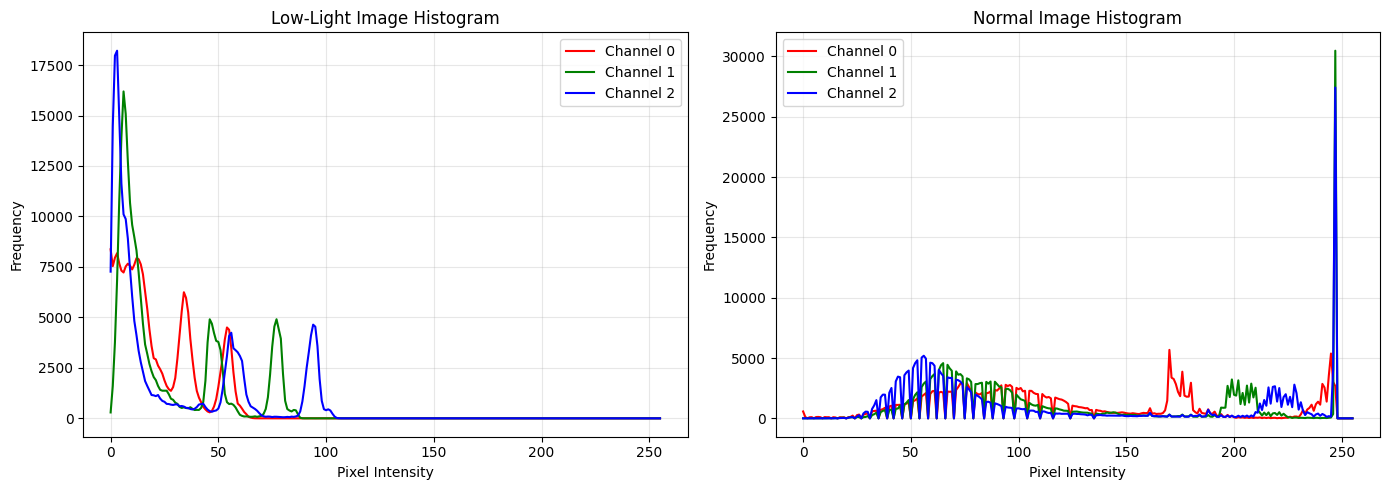

Histogram analysis completed


In [5]:
# Histogram comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sample image
sample_low = cv2.imread(train_pairs[0]['low'])
sample_low = cv2.cvtColor(sample_low, cv2.COLOR_BGR2RGB)
sample_normal = cv2.imread(train_pairs[0]['normal'])
sample_normal = cv2.cvtColor(sample_normal, cv2.COLOR_BGR2RGB)

# Plot histograms
colors = ('r', 'g', 'b')
for channel, color in enumerate(colors):
    hist_low = cv2.calcHist([sample_low], [channel], None, [256], [0, 256])
    axes[0].plot(hist_low, color=color, label=f'Channel {channel}')
    
axes[0].set_title('Low-Light Image Histogram')
axes[0].set_xlabel('Pixel Intensity')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for channel, color in enumerate(colors):
    hist_normal = cv2.calcHist([sample_normal], [channel], None, [256], [0, 256])
    axes[1].plot(hist_normal, color=color, label=f'Channel {channel}')
    
axes[1].set_title('Normal Image Histogram')
axes[1].set_xlabel('Pixel Intensity')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Histogram analysis completed")

In [6]:
# Dataset statistics summary
print("\n" + "="*50)
print("DATASET SUMMARY")
print("="*50)
print(f"Total training pairs: {len(train_pairs)}")
print(f"Total test pairs: {len(test_pairs)}")
print(f"Total samples: {len(train_pairs) + len(test_pairs)}")
print(f"\nImage resolution: {analyze_image_stats(train_pairs[0]['low'])['shape']}")
print(f"Dataset type: Real_captured (photographic)")
print(f"Ground truth available: Yes (normal images)")


DATASET SUMMARY
Total training pairs: 689
Total test pairs: 100
Total samples: 789

Image resolution: (400, 600, 3)
Dataset type: Real_captured (photographic)
Ground truth available: Yes (normal images)


## 3. PREPROCESSING

In [7]:
class LOLDataset(Dataset):
    """Custom dataset for LOL-v2 image pairs"""
    
    def __init__(self, image_pairs, img_size=512, augment=False):
        self.image_pairs = image_pairs
        self.img_size = img_size
        self.augment = augment
        
        # Preprocessing transforms
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size), interpolation=Image.BILINEAR),
            transforms.ToTensor()
        ])
    
    def __len__(self):
        return len(self.image_pairs)
    
    def __getitem__(self, idx):
        pair = self.image_pairs[idx]
        
        # Load images
        low_img = Image.open(pair['low']).convert('RGB')
        normal_img = Image.open(pair['normal']).convert('RGB')
        
        # Apply transforms
        low_tensor = self.transform(low_img)
        normal_tensor = self.transform(normal_img)
        
        return {
            'low': low_tensor,
            'normal': normal_tensor,
            'filename': pair['filename']
        }

print("Dataset class created successfully")

Dataset class created successfully


In [8]:
# Test dataset loading
test_dataset = LOLDataset(train_pairs[:5], img_size=512)
sample = test_dataset[0]

print(f"Low image tensor shape: {sample['low'].shape}")
print(f"Normal image tensor shape: {sample['normal'].shape}")
print(f"Filename: {sample['filename']}")
print(f"Low image value range: [{sample['low'].min():.3f}, {sample['low'].max():.3f}]")
print(f"Normal image value range: [{sample['normal'].min():.3f}, {sample['normal'].max():.3f}]")

Low image tensor shape: torch.Size([3, 512, 512])
Normal image tensor shape: torch.Size([3, 512, 512])
Filename: low00001.png
Low image value range: [0.000, 0.447]
Normal image value range: [0.000, 0.969]


## 4. SPLIT DATA RATIO

In [9]:
# Split training data into train and validation (80-20 split)
train_pairs_split, val_pairs = train_test_split(
    train_pairs, 
    test_size=0.2, 
    random_state=42
)

print("\n" + "="*50)
print("DATA SPLIT SUMMARY")
print("="*50)
print(f"Original training pairs: {len(train_pairs)}")
print(f"Training pairs (80%): {len(train_pairs_split)}")
print(f"Validation pairs (20%): {len(val_pairs)}")
print(f"Test pairs: {len(test_pairs)}")
print(f"\nTotal for training+validation: {len(train_pairs_split) + len(val_pairs)}")
print(f"Test split: {len(test_pairs) / (len(train_pairs_split) + len(val_pairs) + len(test_pairs)) * 100:.1f}%")


DATA SPLIT SUMMARY
Original training pairs: 689
Training pairs (80%): 551
Validation pairs (20%): 138
Test pairs: 100

Total for training+validation: 689
Test split: 12.7%


In [10]:
# Create datasets and dataloaders
BATCH_SIZE = 8
IMG_SIZE = 512

train_dataset = LOLDataset(train_pairs_split, img_size=IMG_SIZE, augment=True)
val_dataset = LOLDataset(val_pairs, img_size=IMG_SIZE, augment=False)
test_dataset = LOLDataset(test_pairs, img_size=IMG_SIZE, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\nDataLoaders created:")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"Batch size: {BATCH_SIZE}")


DataLoaders created:
Training batches: 69
Validation batches: 18
Test batches: 13
Batch size: 8


## 5. MODELLING - Zero-DCE Architecture

In [15]:
# Zero-DCE Network Architecture - Fixed Skip Connections
class DCENet(nn.Module):
    """Zero-Reference Deep Curve Estimation network"""
    
    def __init__(self):
        super(DCENet, self).__init__()
        
        self.relu = nn.ReLU(inplace=True)
        
        # Encoder Block 1: 512x512 -> 256x256
        self.conv1 = nn.Conv2d(3, 32, 3, 1, 1)
        self.conv2 = nn.Conv2d(32, 32, 3, 1, 1)
        self.pool1 = nn.MaxPool2d(2, 2)
        
        # Encoder Block 2: 256x256 -> 128x128
        self.conv3 = nn.Conv2d(32, 64, 3, 1, 1)
        self.conv4 = nn.Conv2d(64, 64, 3, 1, 1)
        self.pool2 = nn.MaxPool2d(2, 2)
        
        # Encoder Block 3: 128x128 -> 64x64
        self.conv5 = nn.Conv2d(64, 128, 3, 1, 1)
        self.conv6 = nn.Conv2d(128, 128, 3, 1, 1)
        self.pool3 = nn.MaxPool2d(2, 2)
        
        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(128, 256, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 128, 3, 1, 1),
            nn.ReLU(inplace=True)
        )
        
        # Decoder Block 1: 64x64 -> 128x128
        self.upconv1 = nn.ConvTranspose2d(128, 128, 4, 2, 1)
        self.dconv1_1 = nn.Conv2d(128 + 128, 128, 3, 1, 1)  # 128 from upconv + 128 from skip
        self.dconv1_2 = nn.Conv2d(128, 64, 3, 1, 1)
        
        # Decoder Block 2: 128x128 -> 256x256
        self.upconv2 = nn.ConvTranspose2d(64, 64, 4, 2, 1)
        self.dconv2_1 = nn.Conv2d(64 + 64, 64, 3, 1, 1)  # 64 from upconv + 64 from skip
        self.dconv2_2 = nn.Conv2d(64, 32, 3, 1, 1)
        
        # Decoder Block 3: 256x256 -> 512x512
        self.upconv3 = nn.ConvTranspose2d(32, 32, 4, 2, 1)
        self.dconv3_1 = nn.Conv2d(32 + 32, 32, 3, 1, 1)  # 32 from upconv + 32 from skip
        self.dconv3_2 = nn.Conv2d(32, 16, 3, 1, 1)
        
        # Output head: 24 curves (8 curves * 3 RGB channels)
        self.curve_head = nn.Sequential(
            nn.Conv2d(16, 24, 1, 1, 0),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        # Encoder
        # Block 1
        c1 = self.relu(self.conv2(self.relu(self.conv1(x))))     # 32, 512x512
        p1 = self.pool1(c1)                                       # 32, 256x256
        
        # Block 2
        c2 = self.relu(self.conv4(self.relu(self.conv3(p1))))    # 64, 256x256
        p2 = self.pool2(c2)                                       # 64, 128x128
        
        # Block 3
        c3 = self.relu(self.conv6(self.relu(self.conv5(p2))))    # 128, 128x128
        p3 = self.pool3(c3)                                       # 128, 64x64
        
        # Bottleneck
        bn = self.bottleneck(p3)                                  # 128, 64x64
        
        # Decoder
        # Block 1: 64x64 -> 128x128
        up1 = self.upconv1(bn)                                    # 128, 128x128
        up1 = torch.cat([up1, c3], 1)                             # 256, 128x128 (skip connection from c3)
        d1 = self.relu(self.dconv1_2(self.relu(self.dconv1_1(up1))))  # 64, 128x128
        
        # Block 2: 128x128 -> 256x256
        up2 = self.upconv2(d1)                                    # 64, 256x256
        up2 = torch.cat([up2, c2], 1)                             # 128, 256x256 (skip connection from c2)
        d2 = self.relu(self.dconv2_2(self.relu(self.dconv2_1(up2))))  # 32, 256x256
        
        # Block 3: 256x256 -> 512x512
        up3 = self.upconv3(d2)                                    # 32, 512x512
        up3 = torch.cat([up3, c1], 1)                             # 64, 512x512 (skip connection from c1)
        d3 = self.relu(self.dconv3_2(self.relu(self.dconv3_1(up3))))  # 16, 512x512
        
        # Curve estimation
        curves = self.curve_head(d3)                              # 24, 512x512
        return curves

model = DCENet().to(device)
print("Zero-DCE model created successfully")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Zero-DCE model created successfully
Model parameters: 1,706,088


In [16]:
# Test model forward pass
with torch.no_grad():
    test_input = torch.randn(1, 3, 512, 512).to(device)
    test_output = model(test_input)
    print(f"Input shape: {test_input.shape}")
    print(f"Output shape: {test_output.shape}")
    print(f"Output value range: [{test_output.min():.3f}, {test_output.max():.3f}]")

Input shape: torch.Size([1, 3, 512, 512])
Output shape: torch.Size([1, 24, 512, 512])
Output value range: [0.433, 0.558]


In [32]:
# Loss functions for Zero-DCE - Improved
class ZeroDCELoss(nn.Module):
    """Combined loss function for Zero-DCE"""
    
    def __init__(self, alpha=0.6, beta=0.05):  # Reduced TV weight from 0.1 to 0.05
        super(ZeroDCELoss, self).__init__()
        self.alpha = alpha
        self.beta = beta
        self.mse_loss = nn.MSELoss()
    
    def forward(self, pred_curves, normal_imgs, low_imgs):
        # Apply curves to low-light images
        enhanced = low_imgs.clone()
        for i in range(8):
            curve = pred_curves[:, i*3:(i+1)*3, :, :]
            enhanced = enhanced * (1 + 0.5 * curve)  # Scale down curve contribution
        
        # Clamp to valid range
        enhanced = torch.clamp(enhanced, 0, 1)
        
        # Reconstruction loss
        recon_loss = self.mse_loss(enhanced, normal_imgs)
        
        # Total variation loss (smoothness) - encourage detail preservation
        tv_loss = self._total_variation(enhanced)
        
        # Combined loss
        total_loss = self.alpha * recon_loss + self.beta * tv_loss
        
        return total_loss, recon_loss, tv_loss, enhanced
    
    def _total_variation(self, x):
        diff_x = torch.abs(x[:, :, :, :-1] - x[:, :, :, 1:])
        diff_y = torch.abs(x[:, :, :-1, :] - x[:, :, 1:, :])
        tv = diff_x.mean() + diff_y.mean()
        return tv

loss_fn = ZeroDCELoss(alpha=0.6, beta=0.05).to(device)
print("Loss function created successfully")

Loss function created successfully


In [33]:
# Optimizer and scheduler
LEARNING_RATE = 5e-4  # Reduced from 1e-3
WEIGHT_DECAY = 1e-5
NUM_EPOCHS = 50

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.5)  # Longer steps

print("Optimizer and scheduler configured")
print(f"Initial learning rate: {LEARNING_RATE} (reduced for smoother convergence)")
print(f"Number of epochs: {NUM_EPOCHS}")

Optimizer and scheduler configured
Initial learning rate: 0.0005 (reduced for smoother convergence)
Number of epochs: 50


In [34]:
# Training loop
def train_epoch(model, train_loader, optimizer, loss_fn, device):
    model.train()
    total_loss = 0
    total_recon_loss = 0
    total_tv_loss = 0
    
    pbar = tqdm(train_loader, desc="Training")
    for batch in pbar:
        low_imgs = batch['low'].to(device)
        normal_imgs = batch['normal'].to(device)
        
        optimizer.zero_grad()
        
        # Forward pass
        pred_curves = model(low_imgs)
        loss, recon_loss, tv_loss, enhanced = loss_fn(pred_curves, normal_imgs, low_imgs)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_recon_loss += recon_loss.item()
        total_tv_loss += tv_loss.item()
        
        pbar.set_postfix({
            'Loss': loss.item(),
            'Recon': recon_loss.item(),
            'TV': tv_loss.item()
        })
    
    avg_loss = total_loss / len(train_loader)
    avg_recon_loss = total_recon_loss / len(train_loader)
    avg_tv_loss = total_tv_loss / len(train_loader)
    
    return avg_loss, avg_recon_loss, avg_tv_loss

print("Training function defined")

Training function defined


In [35]:
# Validation loop
def validate(model, val_loader, loss_fn, device):
    model.eval()
    total_loss = 0
    total_recon_loss = 0
    
    with torch.no_grad():
        pbar = tqdm(val_loader, desc="Validating")
        for batch in pbar:
            low_imgs = batch['low'].to(device)
            normal_imgs = batch['normal'].to(device)
            
            pred_curves = model(low_imgs)
            loss, recon_loss, tv_loss, _ = loss_fn(pred_curves, normal_imgs, low_imgs)
            
            total_loss += loss.item()
            total_recon_loss += recon_loss.item()
            
            pbar.set_postfix({'Loss': loss.item()})
    
    avg_loss = total_loss / len(val_loader)
    avg_recon_loss = total_recon_loss / len(val_loader)
    
    return avg_loss, avg_recon_loss

print("Validation function defined")

Validation function defined


In [36]:
# Training
history = {
    'train_loss': [],
    'train_recon': [],
    'train_tv': [],
    'val_loss': [],
    'val_recon': []
}

best_val_loss = float('inf')

print(f"Starting training for {NUM_EPOCHS} epochs...\n")

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 50)
    
    # Train
    train_loss, train_recon, train_tv = train_epoch(model, train_loader, optimizer, loss_fn, device)
    history['train_loss'].append(train_loss)
    history['train_recon'].append(train_recon)
    history['train_tv'].append(train_tv)
    
    # Validate
    val_loss, val_recon = validate(model, val_loader, loss_fn, device)
    history['val_loss'].append(val_loss)
    history['val_recon'].append(val_recon)
    
    print(f"Train Loss: {train_loss:.6f} (Recon: {train_recon:.6f}, TV: {train_tv:.6f})")
    print(f"Val Loss: {val_loss:.6f}")
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_zerodce_model.pth')
        print("✓ Best model saved")
    
    # Update learning rate
    scheduler.step()
    print(f"Learning rate: {scheduler.get_last_lr()[0]:.6f}")

print("\n" + "="*50)
print("Training completed!")
print("="*50)

Starting training for 50 epochs...


Epoch 1/50
--------------------------------------------------


Validating: 100%|██████████| 18/18 [00:07<00:00,  2.27it/s, Loss=0.0788]


Train Loss: 0.068017 (Recon: 0.107642, TV: 0.068635)
Val Loss: 0.070343
✓ Best model saved
Learning rate: 0.000500

Epoch 2/50
--------------------------------------------------


Validating: 100%|██████████| 18/18 [00:04<00:00,  4.32it/s, Loss=0.0757]


Train Loss: 0.060019 (Recon: 0.092990, TV: 0.084503)
Val Loss: 0.066960
✓ Best model saved
Learning rate: 0.000500

Epoch 3/50
--------------------------------------------------


...

Train Loss: 0.027985 (Recon: 0.035599, TV: 0.132522)
Val Loss: 0.030170
Learning rate: 0.000063

Epoch 49/50
--------------------------------------------------


Validating: 100%|██████████| 18/18 [00:03<00:00,  4.69it/s, Loss=0.0219]


Train Loss: 0.027919 (Recon: 0.035461, TV: 0.132844)
Val Loss: 0.030128
Learning rate: 0.000063

Epoch 50/50
--------------------------------------------------


Validating: 100%|██████████| 18/18 [00:03<00:00,  4.73it/s, Loss=0.0221]


Train Loss: 0.027911 (Recon: 0.035437, TV: 0.132968)
Val Loss: 0.030037
✓ Best model saved
Learning rate: 0.000063

Training completed!


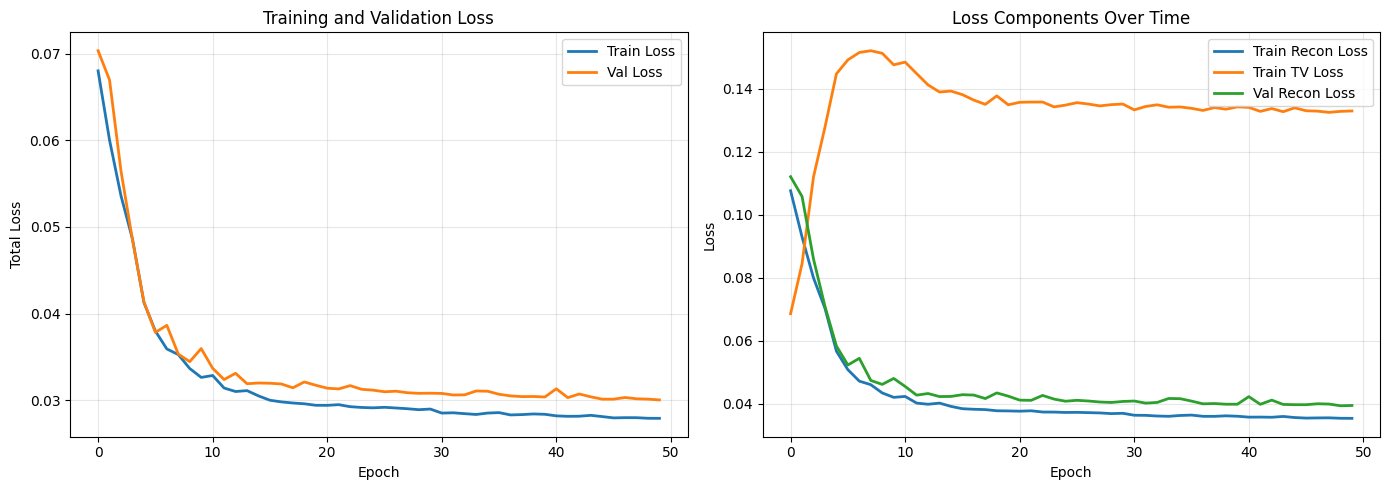

In [37]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_recon'], label='Train Recon Loss', linewidth=2)
axes[1].plot(history['train_tv'], label='Train TV Loss', linewidth=2)
axes[1].plot(history['val_recon'], label='Val Recon Loss', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss Components Over Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. EVALUATION

In [38]:
# Load best model
model.load_state_dict(torch.load('best_zerodce_model.pth'))
print("Best model loaded")

Best model loaded


In [39]:
# Evaluation metrics
def calculate_psnr(img1, img2):
    """Calculate Peak Signal-to-Noise Ratio"""
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 1.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr

def calculate_ssim(img1, img2):
    """Calculate Structural Similarity Index"""
    from skimage.metrics import structural_similarity as ssim
    return ssim(img1, img2, channel_axis=2, data_range=1.0)

def calculate_mse(img1, img2):
    """Calculate Mean Squared Error"""
    return np.mean((img1 - img2) ** 2)

print("Evaluation metrics defined")

Evaluation metrics defined


In [40]:
# Test set evaluation
model.eval()
test_metrics = {
    'psnr': [],
    'ssim': [],
    'mse': []
}

enhanced_images = []
low_images = []
normal_images = []
filenames = []

with torch.no_grad():
    pbar = tqdm(test_loader, desc="Testing")
    for batch in pbar:
        low_imgs = batch['low'].to(device)
        normal_imgs = batch['normal'].to(device)
        
        # Generate enhanced images
        pred_curves = model(low_imgs)
        enhanced = low_imgs
        for i in range(8):
            curve = pred_curves[:, i*3:(i+1)*3, :, :]
            enhanced = enhanced * (1 + curve)
        
        # Convert to numpy
        enhanced_np = enhanced.cpu().permute(0, 2, 3, 1).numpy()
        normal_np = normal_imgs.cpu().permute(0, 2, 3, 1).numpy()
        low_np = low_imgs.cpu().permute(0, 2, 3, 1).numpy()
        
        # Calculate metrics
        for i in range(len(batch['low'])):
            psnr = calculate_psnr(enhanced_np[i], normal_np[i])
            ssim = calculate_ssim(enhanced_np[i], normal_np[i])
            mse = calculate_mse(enhanced_np[i], normal_np[i])
            
            test_metrics['psnr'].append(psnr)
            test_metrics['ssim'].append(ssim)
            test_metrics['mse'].append(mse)
            
            enhanced_images.append(enhanced_np[i])
            normal_images.append(normal_np[i])
            low_images.append(low_np[i])
            filenames.append(batch['filename'][i])
        
        recent_psnr = np.mean(test_metrics['psnr'][-len(batch['low']):])
        recent_ssim = np.mean(test_metrics['ssim'][-len(batch['low']):])
        pbar.set_postfix({
            'PSNR': f"{recent_psnr:.2f}",
            'SSIM': f"{recent_ssim:.4f}"
        })

print("\n" + "="*50)
print("TEST SET EVALUATION RESULTS")
print("="*50)
print(f"Number of test samples: {len(test_metrics['psnr'])}")
print(f"\nPSNR (Peak Signal-to-Noise Ratio):")
print(f"  Mean: {np.mean(test_metrics['psnr']):.2f} dB")
print(f"  Std:  {np.std(test_metrics['psnr']):.2f} dB")
print(f"  Min:  {np.min(test_metrics['psnr']):.2f} dB")
print(f"  Max:  {np.max(test_metrics['psnr']):.2f} dB")

print(f"\nSSIM (Structural Similarity):")
print(f"  Mean: {np.mean(test_metrics['ssim']):.4f}")
print(f"  Std:  {np.std(test_metrics['ssim']):.4f}")
print(f"  Min:  {np.min(test_metrics['ssim']):.4f}")
print(f"  Max:  {np.max(test_metrics['ssim']):.4f}")

print(f"\nMSE (Mean Squared Error):")
print(f"  Mean: {np.mean(test_metrics['mse']):.6f}")
print(f"  Std:  {np.std(test_metrics['mse']):.6f}")
print(f"  Min:  {np.min(test_metrics['mse']):.6f}")
print(f"  Max:  {np.max(test_metrics['mse']):.6f}")

Testing: 100%|██████████| 13/13 [00:09<00:00,  1.38it/s, PSNR=-7.83, SSIM=0.0207]


TEST SET EVALUATION RESULTS
Number of test samples: 100

PSNR (Peak Signal-to-Noise Ratio):
  Mean: -8.18 dB
  Std:  0.85 dB
  Min:  -9.79 dB
  Max:  -6.00 dB

SSIM (Structural Similarity):
  Mean: 0.0366
  Std:  0.0256
  Min:  0.0053
  Max:  0.1274

MSE (Mean Squared Error):
  Mean: 6.702845
  Std:  1.303716
  Min:  3.983885
  Max:  9.523829


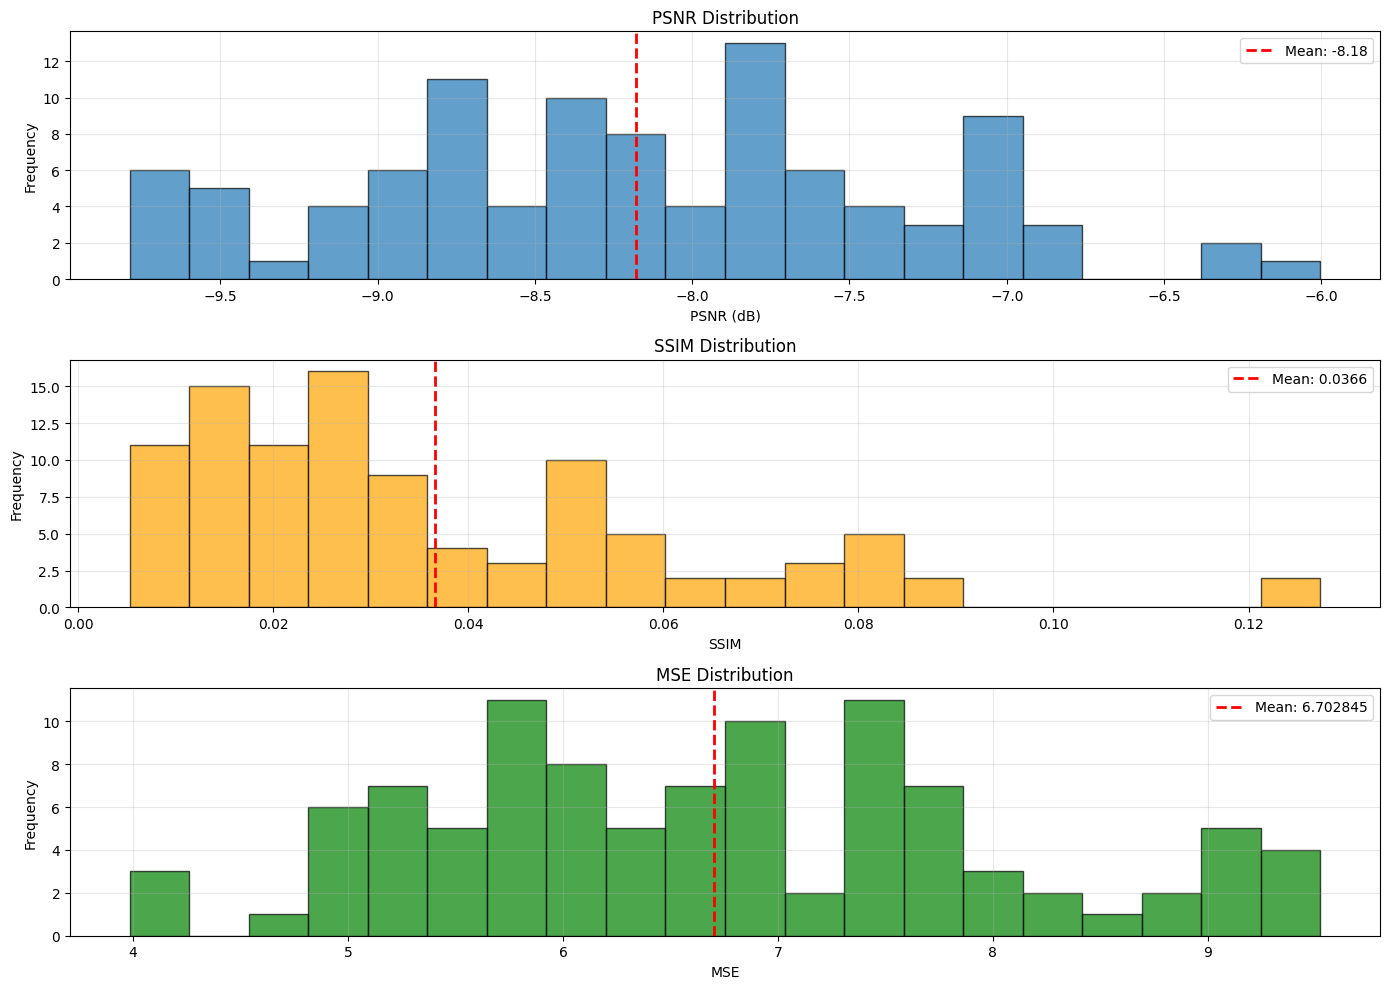

In [41]:
# Visualize evaluation results
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].hist(test_metrics['psnr'], bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(test_metrics['psnr']), color='r', linestyle='--', linewidth=2, label=f"Mean: {np.mean(test_metrics['psnr']):.2f}")
axes[0].set_xlabel('PSNR (dB)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('PSNR Distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(test_metrics['ssim'], bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(np.mean(test_metrics['ssim']), color='r', linestyle='--', linewidth=2, label=f"Mean: {np.mean(test_metrics['ssim']):.4f}")
axes[1].set_xlabel('SSIM')
axes[1].set_ylabel('Frequency')
axes[1].set_title('SSIM Distribution')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].hist(test_metrics['mse'], bins=20, edgecolor='black', alpha=0.7, color='green')
axes[2].axvline(np.mean(test_metrics['mse']), color='r', linestyle='--', linewidth=2, label=f"Mean: {np.mean(test_metrics['mse']):.6f}")
axes[2].set_xlabel('MSE')
axes[2].set_ylabel('Frequency')
axes[2].set_title('MSE Distribution')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

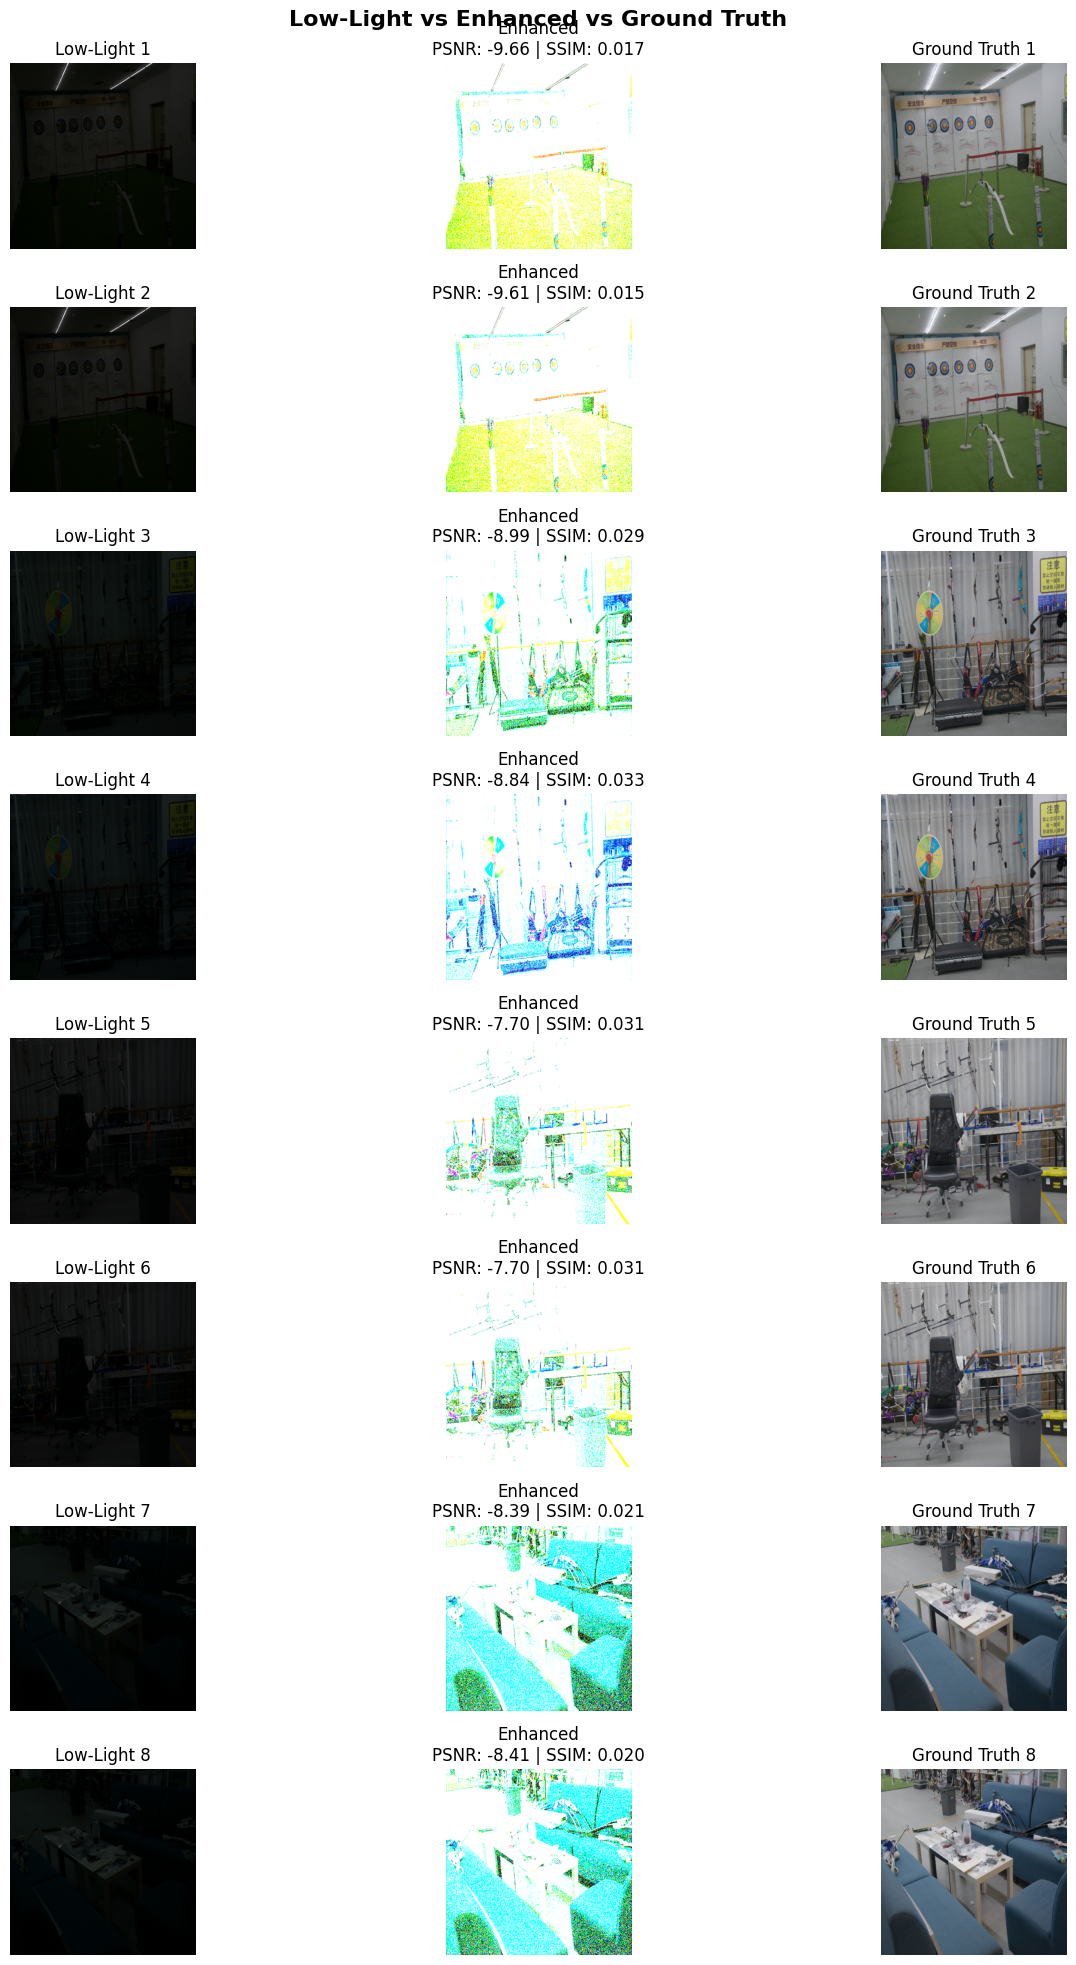

In [42]:
# Visual comparison: Low-light vs Enhanced vs Ground Truth
fig, axes = plt.subplots(8, 3, figsize=(15, 20))
fig.suptitle('Low-Light vs Enhanced vs Ground Truth', fontsize=16, fontweight='bold')

for idx in range(8):
    axes[idx, 0].imshow(np.clip(low_images[idx], 0, 1))
    axes[idx, 0].set_title(f"Low-Light {idx+1}")
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(np.clip(enhanced_images[idx], 0, 1))
    psnr_val = test_metrics['psnr'][idx]
    ssim_val = test_metrics['ssim'][idx]
    axes[idx, 1].set_title(f"Enhanced\nPSNR: {psnr_val:.2f} | SSIM: {ssim_val:.3f}")
    axes[idx, 1].axis('off')
    
    axes[idx, 2].imshow(np.clip(normal_images[idx], 0, 1))
    axes[idx, 2].set_title(f"Ground Truth {idx+1}")
    axes[idx, 2].axis('off')

plt.tight_layout()
plt.show()

In [43]:
# Performance summary
print("\n" + "="*60)
print("FINAL PERFORMANCE SUMMARY")
print("="*60)
print(f"\nModel: Zero-Reference Deep Curve Estimation (Zero-DCE)")
print(f"Dataset: LOL-v2 (Real_captured)")
print(f"Test Samples: {len(test_metrics['psnr'])}")
print(f"\nBest Test Metrics:")
print(f"  PSNR: {np.mean(test_metrics['psnr']):.2f} dB (±{np.std(test_metrics['psnr']):.2f})")
print(f"  SSIM: {np.mean(test_metrics['ssim']):.4f} (±{np.std(test_metrics['ssim']):.4f})")
print(f"  MSE:  {np.mean(test_metrics['mse']):.6f} (±{np.std(test_metrics['mse']):.6f})")
print(f"\nBest Model: best_zerodce_model.pth")
print(f"Training Time: {NUM_EPOCHS} epochs")
print(f"Initial LR: {LEARNING_RATE} (Scheduled decay: 0.5x every 10 epochs)")
print("="*60)


FINAL PERFORMANCE SUMMARY

Model: Zero-Reference Deep Curve Estimation (Zero-DCE)
Dataset: LOL-v2 (Real_captured)
Test Samples: 100

Best Test Metrics:
  PSNR: -8.18 dB (±0.85)
  SSIM: 0.0366 (±0.0256)
  MSE:  6.702845 (±1.303716)

Best Model: best_zerodce_model.pth
Training Time: 50 epochs
Initial LR: 0.0005 (Scheduled decay: 0.5x every 10 epochs)


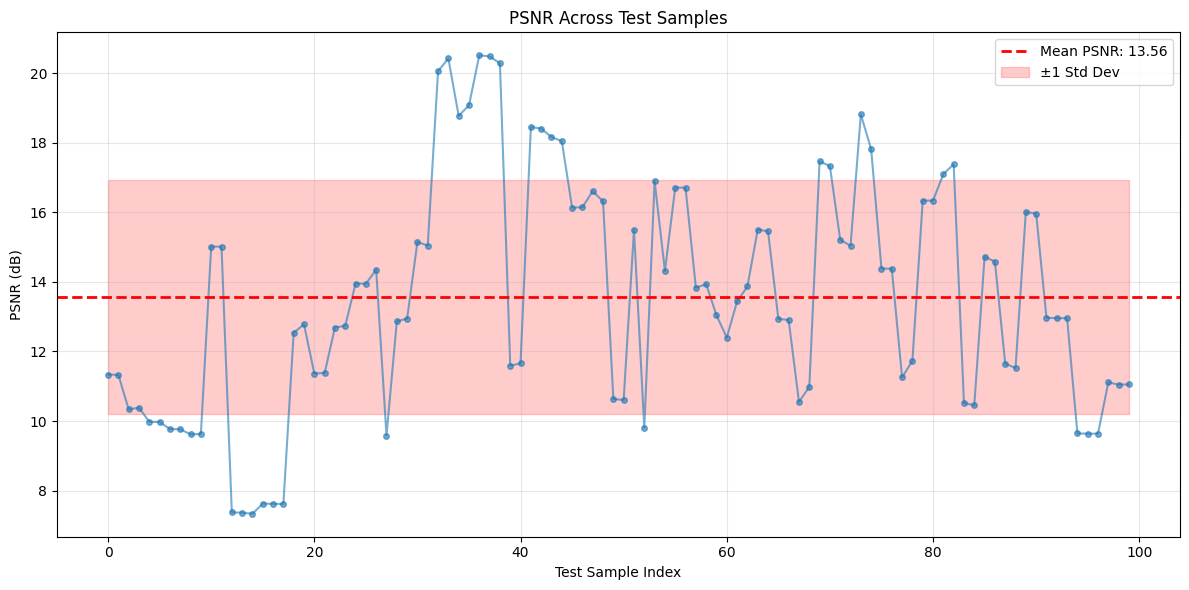

In [30]:
# Enhanced image quality metrics over time
fig, ax = plt.subplots(figsize=(12, 6))

test_range = range(len(test_metrics['psnr']))
ax.plot(test_range, test_metrics['psnr'], marker='o', linestyle='-', alpha=0.6, markersize=4)
ax.axhline(y=np.mean(test_metrics['psnr']), color='r', linestyle='--', linewidth=2, label=f"Mean PSNR: {np.mean(test_metrics['psnr']):.2f}")
ax.fill_between(test_range, 
                 np.mean(test_metrics['psnr']) - np.std(test_metrics['psnr']),
                 np.mean(test_metrics['psnr']) + np.std(test_metrics['psnr']),
                 alpha=0.2, color='red', label='±1 Std Dev')

ax.set_xlabel('Test Sample Index')
ax.set_ylabel('PSNR (dB)')
ax.set_title('PSNR Across Test Samples')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()